# Final Project: Full Computational Model
**Edmund, Greta, Levente, Trenton**

**The Question:** If you know the count of neutrons at a given time in a reactor, are you able to determine what it will be in the future and what it was in the past?

To answer this, first we must understand neutron fission a little. Inside a piece of fissible material such as the uranium in a reactor core, neutrons slam into other nuclei splitting it apart. That split (called fission) not only releases a lot of energy, but it also releases additional neutrons that fly off and slam into other nuclei causing more fission. It becomes a chain reaction of neutrons making more neutrons. However, not every neutron is guarenteed to ensure more splitting. Some simply get absorbed back into nuclei while some leak out of the edges and become unusable and gone. So in each "round" of a reaction only a fraction of the neutrons will succedd in producing more. At its simplest, the behavior of this system can be captured by just looking at a single number called the multiplication factor k- the average number of next round neutrons that each neutron produces. From this we construct the simple equation $N_{n+1}=kN_n$ where $N_n$ is the amount of neutrons at the nth round. This equation is a first order difference equation. Each generation only depends on the previous generation. But repeating this gives us exponential growth or decay, so we can predict many generations into the future. It can be seen that if k > 1 the population must grow over time, if k = 1 then it will remain constant, and if k < 1 then the population will decrease. Actually determining values for k is quite the ordeal by itself so we will just be manually entering common values but more information on how it can be calculated can be found here https://www.nuclear-power.com/nuclear-power/reactor-physics/nuclear-fission-chain-reaction/six-factor-formula-effective-multiplication-factor/neutron-life-cycle/.

Understaning neutron multiplication is super important since nuclear reactors depend on keeping a controlled chain reaction. If neutron population grows too quickly, then the reactor becomes very unsafe. If it decreases too much, then the chain reaction stops. Modeling neutron populations lets us have a better understanding of how a reactor behaves and how it depends on the multiplication factor and the prediction of future neutron populations.  

**Assumptions** 
- Only track the amount of neutrons not the location. Doing this disregards the space itself and treats all the reactions as happening in a "point" but it keeps the thing we care about.
- k is staying constant for each run. In real reactions the value of k will vary and shift during the reaction as a whole but for our sake we will freeze k to see clean behavior.
- Time is measured in discrete generations. Rather than treating time as continous seconds we simply step the reaction forward one "step" where everything happens all at once.
- Neutrons act independently. Each neutron isn't effected by the state of other neutrons and acts as its own.

**Model Construction**
1. Identify the physical process (neutron multiplication).
2. Simplify the system with assumptions.
3. Create a deterministic model.
4. Compare the behavior for different values of multiplication factors.
5. Extend the model to include randomness through a branching process.
6. Compare the deterministic and stochastic predictions.

To look at how the multiplication factor actually affects the neutron populations, we look at three different systems. One is the subcritical (k<1), one is the critical (k=1), and one is supercritical (k>1). By looking at these three cases, we are able to see how such small differences in the neutron multiplication could lead to very different outcomes in the long run. 

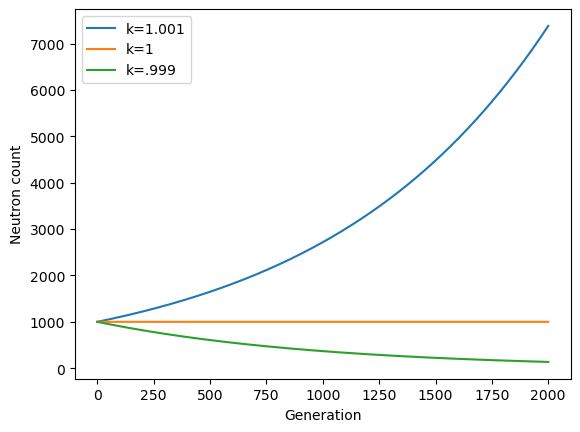

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def growd(N0,k,n): #Fisrt we create a simple function that takes in a inital neutron count and outputs the future count for n generations using the k value
    N=[N0]
    for i in range(n):
        N.append(k*N[-1])
    return N

#Initiliaze
N0=1000
n=2000
gen=np.arange(n+1)

#Then we'll run and plot for three different k values to capture each behavior
N1=growd(N0,1.001,n)
N2=growd(N0,1,n)
N3=growd(N0,.999,n)
plt.plot(gen,N1,label="k=1.001")
plt.plot(gen,N2,label="k=1")
plt.plot(gen,N3,label="k=.999")
plt.legend()
plt.xlabel("Generation")
plt.ylabel("Neutron count")
plt.show()

These results seem to match our expectations of reactor physics. The subcritical system ends up losing neutrons and then goes to zero, and the critical system remains with a constant population. The supercritical system has pretty continuous growth. Even though the multiplication factors are different but only by a small amount, the neutron populations are very different after multiple generations.

So using this framework are we able to answer our question? Well as long as k stays constant and I'm given the value of the population at any generation then yes, I am able to determine the population at any generation since all it's doing is moving forward or backward by powers of k.

The first model lets us to look at the original question pretty well. If we know the neutron population at a single generation and we know the multiplication factor, are we able to figure out the population at all other generations? To look at this, we generated a neutron history and then pretended that we only know one point from that history.

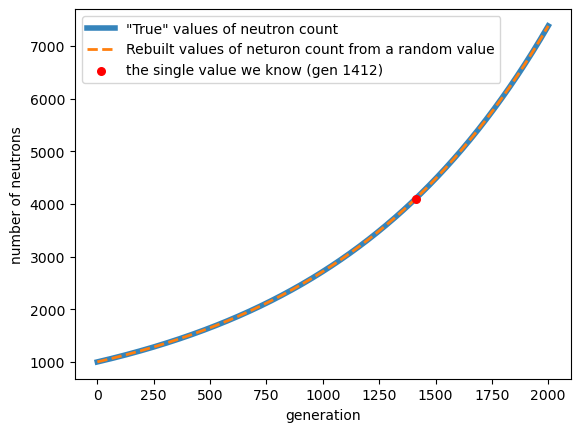

In [31]:
#True population initally constructed
k=1.001
N0=1000
n=2000
gen=np.arange(n+1)
trueN=growd(N0,k,n)

#Now imagine we were only given the count at a generation
gk=np.random.randint(500, n-500)  
Nk=trueN[gk]

#Then we can simply rebuild our values by raising it to powers of k negative and postive
rebuilt=Nk*k**(gen-gk)

#Now plot and compare
plt.plot(gen,trueN,label='"True" values of neutron count',alpha=.9,lw=4)
plt.plot(gen,rebuilt,label="Rebuilt values of neturon count from a random value",ls="--",lw=2)
plt.scatter([gk], [Nk],color="red",zorder=8,s=30,label=f"the single value we know (gen {gk})")
plt.xlabel("generation")
plt.ylabel("number of neutrons")
plt.legend()
plt.show()

So clearly from our assumptions using this model yes we are able to predict future and past generations of neutron count what felt quite easily. Where things get more complicated is if we now disregard the idea of neturon count being a continous smooth number but rather a discrete number.

The smooth model has the inherent assumption that the neutron count is a large enough number to where it basically behaves continously where I can simply multiply by k to recieve a whole number. The caveat is that neutrons are physically discrete countable things and it doesn't make physica sense to have one neutron split into 1.02 neutrons. In reality, a neutron either collides and produces a few neutrons or it gets absorbed and is taken out of count. When the population is large enough then yes these coin flips average out nicely to our model above but what if it's smaller?

The reconstructed curve is basically directly on top of the original curve. This happens because the deterministic model does not have any randomness. Every neutron generation is determined in its own way by the past generation, so that one known population value is good enough to recover the entire history of the system. With the assumptions of the model, both the future and past populations can be predicted.

This time instead of just multiplying the whole population by k we will treat each neutron individually and each neutron will produce a random amount of offspring that averages to our value of k. This type of approach is called a branching process https://en.wikipedia.org/wiki/Branching_process.

The deterministic model is helpful, but it treats the neutron populations as continuous. Real neutrons are discrete particles, and neutron production is probabilistic. Individual neutrons themselves might give us different numbers of offspring, and these random fluctuations are more important when populations are small. To account for this, we are using a branching process model.

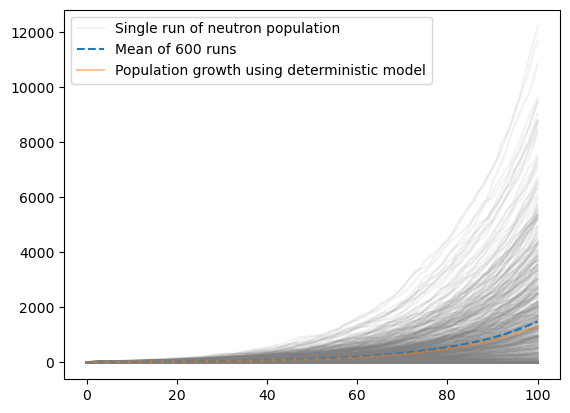

In [109]:
rng=np.random.default_rng() #
def grows(N0,k,n,rng):
    N=[N0]
    for i in range(n):
        N.append(rng.poisson(k*N[i]))
    return N
N0=10
k=1.05
n=100
trials=600
gen=np.arange(n+1)
runs=np.zeros((trials,n+1))
for i in range(trials):
    runs[i]=grows(N0,k,n,rng)
    plt.plot(gen,runs[i],alpha=.1,color="gray")
plt.plot(gen,runs[-1],alpha=.1,color="gray",label="Single run of neutron population")
N=runs.mean(axis=0)
plt.plot(gen,N,label=f"Mean of {trials} runs",ls="--")
Nt=growd(N0,k,n)
plt.plot(gen,Nt,alpha=.45,label="Population growth using deterministic model")
plt.legend()
plt.show()

In [110]:
gk=50
j=np.random.randint(0,200)
radius=500
unc=10
pointruns=[]
for i in range(trials):
    if abs(radius-runs[i][gk])<=unc:
        pointruns.append(runs[i])
        

The gray curves show the individual realizations of the neutron population, and the dashed curve shows the average behavior of all of the simulations. The individual runs themselves can differ, but the average follows the deterministic prediction well. This shows that the deterministic model is able to capture the average behavior of the system, even though individual neutron histories vary because of chance.

The deterministic model suggests that one known neutron population value will determines the entire history of the system. We can test whether that is true in the stochastic model. We chose simulations that have roughly the same neutron population at a particular generation and look at how their histories chnage before and after that point.

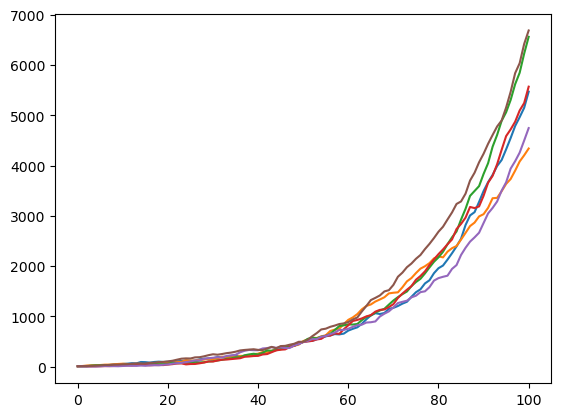

In [111]:
for i in range(len(pointruns)):
    plt.plot(gen,pointruns[i])

This final figure shows one of the biggest differences between the deterministic and stochastic models. In the deterministic model, if we know the neutron populationa of a single generation will determine the population at ealier and later generations. All of the points seem to lie on one exact possible trajectory. However for the other model, the different histories of neutrons is able to pass through roughly the same neutron population of a given generation. The histories seem to have similar populations at 50, they can have very different populations before that and after. So knowing the neutron count at one moment isn't the best way to reconstruct or predict the future. 

**Limitations of the Model**

Our model does capture the basic behavior of neutron multiplication, but there are many simplifications that were made.

- The multiplication factor k was assumed to stay constant throughout the simulation.
- Spatial effects were ignored, so that neutron position and movement through the reactor were not modeled.
- Time was treated as discrete generations instead of continuous time.
- Neutrons were assumed to act independently.
- The deterministic model allows fractional neutron populations, which is not physically realistic.
- Delayed neutrons were not included.
- Fuel depletion and changing reactor conditions were ignored.

Because of these assumptions, the model should be seen as a simplified representation of neutron multiplication instead of a complete reactor simulation.

**Conclusion**

The goal of this project was to find out whether knowing the neutron population at a single point in time is enough to predict the neutron population in the future and rebuild it from the past. Using a deterministic model with a constant multiplication factor k, we found that the answer is yes. Since each generation is related to the previous generation through an exponential relationship, a known population value can be used to find the entire neutron history of the system.

But, when we extended the model to include the randomness of neutron production with a branching process, the situation changed. The average behavior of many simulations still agreed well with the deterministic prediction, but the individual neutron histories changed significantly. Multiple simulations could pass through nearly the same neutron population at a given generation but still have very different histories before and after that point. This means that in a stochastic system, knowing the neutron population at one moment is not good enough to determine the past or future of the system.

Overall, our models show that neutron multiplication can be described well by a simple exponential model for the most part, but randomness is very important when we look at individual neutron histories. The deterministic model gives a useful first approximation, and the stochastic model gives a more realistic representation of how neutron populations evolve in physical systems.